# Tarea 1 Por Juan Pablo Ramirez

## Punto uno

$$
\begin{aligned}
&\text{Se cumple la identidad:} \\
&\quad \text{rms}^2_w(x) = \text{avg}^2_w(x) + \text{std}^2_w(x) \\
\\
&\text{donde } w_1, w_2, \ldots, w_n \text{ son pesos positivos tales que la suma total de los pesos es:} \\
&\quad W = \sum_{i=1}^n w_i > 0 \\
\\
&\text{y donde tenemos las definiciones:} \\
&\quad \text{avg}_w(x) = \frac{1}{W} \sum_{i=1}^n w_i x_i \\
&\quad \text{std}^2_w(x) = \frac{1}{W} \sum_{i=1}^n w_i \left(x_i - \text{avg}_w(x)\right)^2 \\
&\quad \text{rms}_w(x) = \sqrt{ \frac{1}{W} \sum_{i=1}^n w_i x_i^2 }
\end{aligned}
$$


$$
\begin{aligned}
&\text{entonces }\\ &\text{rms}_w^2(x) = \frac{1}{W} \sum_{i=1}^n w_i x_i^2 \\
\\
&\text{ademas expandiendo}\\ 

&\text{std}_w^2(x) = \frac{1}{W} \sum_{i=1}^n w_i (x_i - \text{avg}_w(x))^2 \\
&= \frac{1}{W} \sum_{i=1}^n w_i \left( x_i^2 - 2x_i  \text{avg}_w(x) + \text{avg}_w^2(x) \right) \\
&= \frac{1}{W} \left( \sum_{i=1}^n w_i x_i^2 - 2 \text{avg}_w(x) \sum_{i=1}^n w_i x_i + \text{avg}_w^2(x) \sum_{i=1}^n w_i \right) \\
&= \frac{1}{W} \left( \sum_{i=1}^n w_i x_i^2 - 2W \text{avg}_w^2(x) + W \text{avg}_w^2(x) \right) \\
&= \frac{1}{W} \left( \sum_{i=1}^n w_i x_i^2 - W \text{avg}_w^2(x) \right)\\
&= \frac{1}{W} \sum_{i=1}^n w_i x_i^2 - \text{avg}_w^2(x)
\\
&\text{std}_w^2(x) = \frac{1}{W} \sum_{i=1}^n w_i x_i^2 - \text{avg}_w^2(x) \\
\\
&\text{ademas sumando a ambos lados } \text{avg}_w^2(x) \\ &\text{std}_w^2(x) + \text{avg}_w^2(x) = \frac{1}{W} \sum_{i=1}^n w_i x_i^2  \\
\\
&\text{entonces remplazando por definicion } \text{rms}_w^2(x)\\ &\text{rms}_w^2(x) = \text{avg}_w^2(x) + \text{std}_w^2(x)
\end{aligned}
$$

## Punto Dos

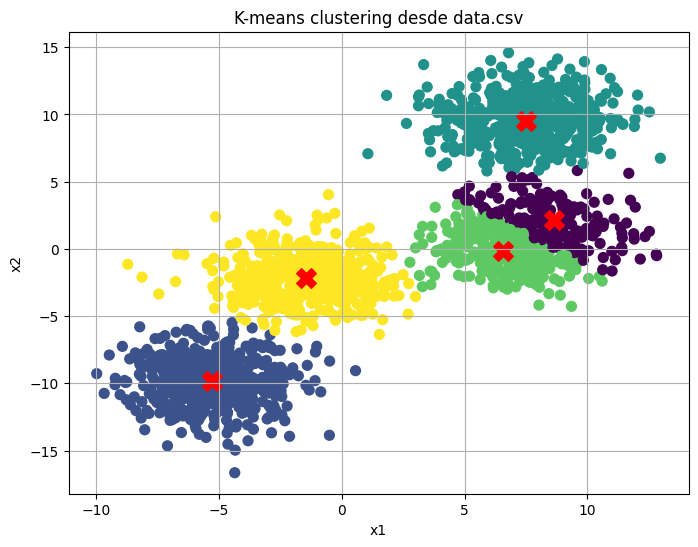

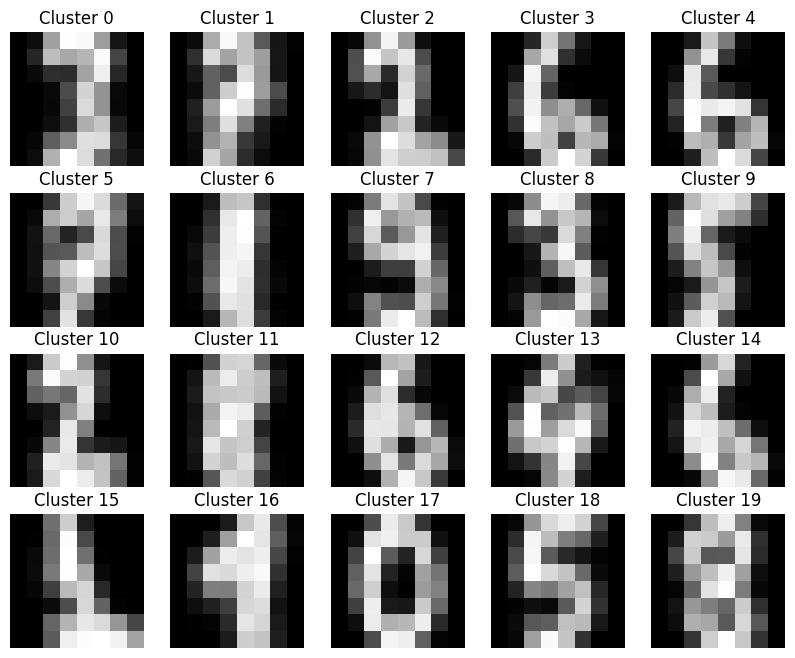

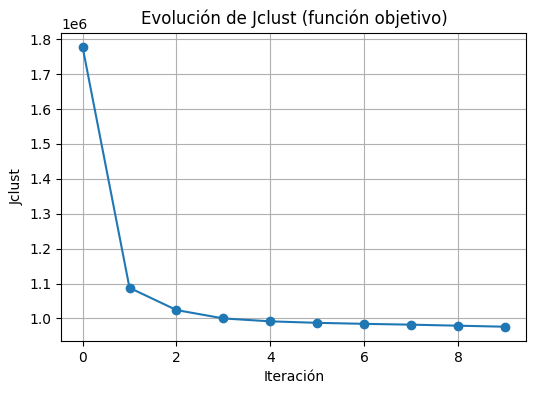

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

# Función k-means 
def k_means_fit(X, Z0, NITERMAX):
    k = Z0.shape[0]
    centroids = Z0.copy()
    j_values = []

    for _ in range(NITERMAX):
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Calcular Jclust (suma de distancias cuadradas)
        j = 0
        for i in range(k):
            cluster_points = X[labels == i]
            j += ((cluster_points - centroids[i])**2).sum()
        j_values.append(j)

        # Actualizar centroides
        for i in range(k):
            if np.any(labels == i):
                centroids[i] = X[labels == i].mean(axis=0)

    return centroids, labels, j_values


def executor(k, file, title):
    # 1. Cargar los datos desde data.csv
    df = pd.read_csv(file)
    X = df.values  # Convertir a matriz numpy

    # 2. Inicializar centroides aleatorios
    np.random.seed(0)
    Z0 = X[np.random.choice(len(X), k, replace=False)]

    # 3. Aplicar k-means
    centroids, labels , j_values= k_means_fit(X, Z0, NITERMAX=10)

    # 4. Graficar resultado
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X')
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True)
    plt.show()

def executor_mnist(k=20, n_iter=10):
    digits = load_digits()
    X = digits.data  # Imágenes aplanadas (64 dimensiones)

    # Inicialización aleatoria de centroides
    np.random.seed(0)
    Z0 = X[np.random.choice(len(X), k, replace=False)]

    # Ejecutar k-means
    centroids, labels, j_values  = k_means_fit(X, Z0, NITERMAX=n_iter)

# Mostrar centroides (como imágenes) y un ejemplo de cada cluster
    fig, axs = plt.subplots(4, 5, figsize=(10, 8))
    for i in range(k):
        axs[i//5, i%5].imshow(centroids[i].reshape(8, 8), cmap='gray')
        axs[i//5, i%5].set_title(f"Cluster {i}")
        axs[i//5, i%5].axis('off')

    # Graficar evolución de la función objetivo
    plt.figure(figsize=(6, 4))
    plt.plot(j_values, marker='o')
    plt.title("Evolución de Jclust (función objetivo)")
    plt.xlabel("Iteración")
    plt.ylabel("Jclust")
    plt.grid(True)
    plt.show()

executor(5, "../data/datakmeans-1.csv", "K-means clustering desde data.csv")
executor_mnist()




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

# Función k-means 
def k_means_fit(X, Z0, NITERMAX):
    k = Z0.shape[0]
    centroids = Z0.copy()
    j_values = []

    for _ in range(NITERMAX):
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Calcular Jclust (suma de distancias cuadradas)
        j = 0
        for i in range(k):
            cluster_points = X[labels == i]
            j += ((cluster_points - centroids[i])**2).sum()
        j_values.append(j)

        # Actualizar centroides
        for i in range(k):
            if np.any(labels == i):
                centroids[i] = X[labels == i].mean(axis=0)

    return centroids, labels, j_values


def executor(k, file, title):
    # 1. Cargar los datos desde data.csv
    df = pd.read_csv(file)
    X = df.values  # Convertir a matriz numpy

    # 2. Inicializar centroides aleatorios
    np.random.seed(0)
    Z0 = X[np.random.choice(len(X), k, replace=False)]

    # 3. Aplicar k-means
    centroids, labels , j_values= k_means_fit(X, Z0, NITERMAX=10)

    # 4. Graficar resultado
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X')
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True)
    plt.show()

def executor_mnist(k=20, n_iter=10):
    digits = load_digits()
    X = digits.data  # Imágenes aplanadas (64 dimensiones)

    # Inicialización aleatoria de centroides
    np.random.seed(0)
    Z0 = X[np.random.choice(len(X), k, replace=False)]

    # Ejecutar k-means
    centroids, labels, j_values  = k_means_fit(X, Z0, NITERMAX=n_iter)

# Mostrar centroides (como imágenes) y un ejemplo de cada cluster
    fig, axs = plt.subplots(4, 5, figsize=(10, 8))
    for i in range(k):
        axs[i//5, i%5].imshow(centroids[i].reshape(8, 8), cmap='gray')
        axs[i//5, i%5].set_title(f"Cluster {i}")
        axs[i//5, i%5].axis('off')

    # Graficar evolución de la función objetivo
    plt.figure(figsize=(6, 4))
    plt.plot(j_values, marker='o')
    plt.title("Evolución de Jclust (función objetivo)")
    plt.xlabel("Iteración")
    plt.ylabel("Jclust")
    plt.grid(True)
    plt.show()

executor(5, "../data/datakmeans-1.csv", "K-means clustering desde data.csv")
executor_mnist()




### Punto Tres
$$
\begin{aligned}
&\textbf{Sistema de ecuaciones:} \\
&x + y + z = 1 \\
&2x - 3y + 4z = 1 \\
&3x + 5y - z = 1 \\
&2y - 4z = -2 \\
\\
&\textbf{Matriz de coeficientes } A \text{ y vector } b: \\
&A =
\begin{bmatrix}
1 & 1 & 1 \\
2 & -3 & 4 \\
3 & 5 & -1 \\
0 & 2 & -4
\end{bmatrix}, \quad
b =
\begin{bmatrix}
1 \\
1 \\
1 \\
-2
\end{bmatrix} \\
\\
&\textbf{Matriz aumentada } [A \,|\, b]: \\
&\begin{bmatrix}
1 & 1 & 1 & | & 1 \\
2 & -3 & 4 & | & 1 \\
3 & 5 & -1 & | & 1 \\
0 & 2 & -4 & | & -2
\end{bmatrix} \\
\\
&\textbf{Reducción por filas:} \\
&R_2 \leftarrow R_2 - 2R_1,\quad R_3 \leftarrow R_3 - 3R_1 \\
&\Rightarrow
\begin{bmatrix}
1 & 1 & 1 & | & 1 \\
0 & -5 & 2 & | & -1 \\
0 & 2 & -4 & | & -2 \\
0 & 2 & -4 & | & -2
\end{bmatrix} \\
&R_3 \leftarrow R_3 + R_2,\quad R_4 \leftarrow R_4 + R_2 \\
&\Rightarrow
\begin{bmatrix}
1 & 1 & 1 & | & 1 \\
0 & -5 & 2 & | & -1 \\
0 & -3 & -2 & | & -3 \\
0 & -3 & -2 & | & -3
\end{bmatrix} \\
&R_4 \leftarrow R_4 - R_3 \Rightarrow \text{fila nula} \\
&\Rightarrow
\begin{bmatrix}
1 & 1 & 1 & | & 1 \\
0 & -5 & 2 & | & -1 \\
0 & -3 & -2 & | & -3 \\
0 & 0 & 0 & | & 0
\end{bmatrix} \\
\\
&\textbf{Análisis de rangos:} \\
&\text{Rango}(A) = 3,\quad \text{Rango}([A \,|\, b]) = 3,\quad n = 3 \\
\\
&\textbf{Conclusión:} \\
&\text{Como } \text{rango}(A) = \text{rango}([A \,|\, b]) = n,\ \text{el sistema tiene solución única (compatible determinado).}
\end{aligned}
$$

In [99]:
import numpy as np

# Definir la matriz de coeficientes A y el vector b
A = np.array([
    [1, 1, 1],
    [2, -3, 4],
    [3, 5, -1],
    [0, 2, -4]
], dtype=float)

b = np.array([1, 1, 1, -2], dtype=float)

# Crear la matriz aumentada [A | b]
Ab = np.hstack((A, b.reshape(-1, 1)))

# Calcular rangos
rango_A = np.linalg.matrix_rank(A)
rango_Ab = np.linalg.matrix_rank(Ab)
num_variables = A.shape[1]

# Mostrar resultados
print("Rango de A:", rango_A)
print("Rango de [A | b]:", rango_Ab)
print("Número de incógnitas:", num_variables)

# Determinar tipo de sistema
if rango_A == rango_Ab:
    if rango_A == num_variables:
        print("Conclusión: El sistema tiene solución única (compatible determinado).")
    else:
        print("Conclusión: El sistema tiene infinitas soluciones (compatible indeterminado).")
else:
    print("Conclusión: El sistema no tiene solución (incompatible).")

Rango de A: 3
Rango de [A | b]: 3
Número de incógnitas: 3
Conclusión: El sistema tiene solución única (compatible determinado).


## Punto Cuatro



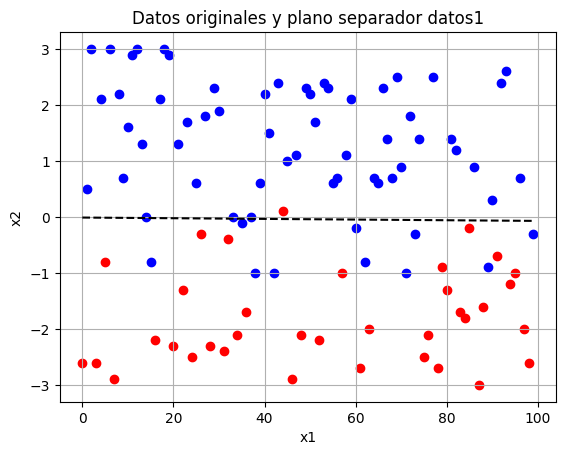

Score en datos de entrenamiento: 0.88
Predicciones en nuevos datos: [-1. -1.  1. -1.  1. -1.  1. -1.  1.  1.  1.  1.  1.  1. -1. -1. -1.  1.
  1.  1. -1.  1. -1.  1. -1.  1. -1.  1. -1.  1.  1. -1. -1.  1. -1. -1.
 -1. -1. -1.  1.  1.  1. -1.  1. -1.  1. -1.  1. -1.  1.  1.  1. -1.  1.
  1. -1.  1. -1.  1.  1.  1. -1. -1. -1.  1.  1.  1.  1.  1.  1.  1. -1.
  1.  1.  1. -1. -1.  1. -1. -1. -1.  1.  1. -1. -1. -1.  1. -1. -1. -1.
 -1. -1.  1.  1. -1. -1.  1. -1. -1.  1.]
Score en nuevos datos: 0.52


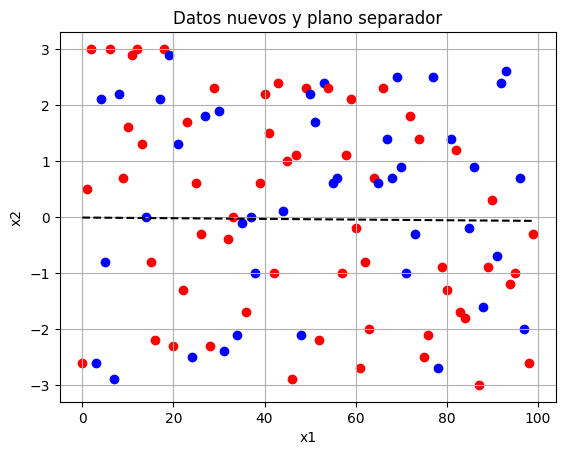

Score en los nuevos datos: 0.7


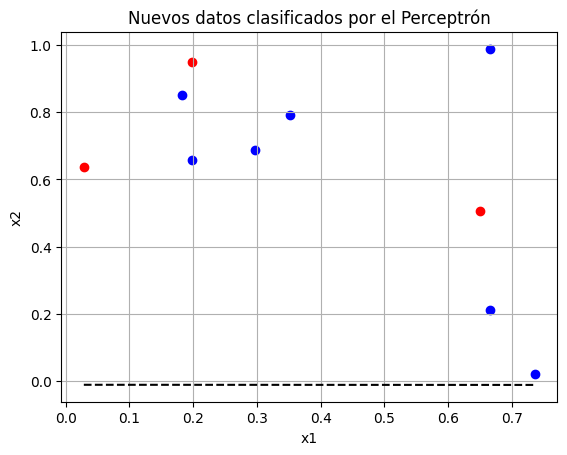

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# a) Algoritmo del Perceptrón
def Perceptron_fit(X, y, nitmax, eta):
    X = np.insert(X, 0, 1, axis=1)  # agregar término de sesgo (bias)
    w = np.zeros(X.shape[1])
    
    for _ in range(nitmax):
        for i in range(X.shape[0]):
            y_pred = np.sign(np.dot(X[i], w))
            if y_pred == 0:
                y_pred = -1  # para evitar que 0 no cuente como clase
            if y[i] != y_pred:
                w += eta * y[i] * X[i]
    return w

# b) Predicción de clases
def predict(w, X):
    X = np.insert(X, 0, 1, axis=1)
    return np.sign(np.dot(X, w))

# c) Score de predicciones correctas
def score(w, X, y):
    y_pred = predict(w, X)
    return np.mean(y_pred == y)

# d) Visualización del plano separador
def plot_data_with_separator(X, y, w, title=""):
    plt.figure()
    for i in range(len(y)):
        color = 'red' if y[i] == -1 else 'blue'
        plt.scatter(X[i, 0], X[i, 1], color=color)
    
    # Recta: w0 + w1*x1 + w2*x2 = 0  => x2 = -(w0 + w1*x1)/w2
    x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    if w[2] != 0:
        y_vals = -(w[0] + w[1] * x_vals) / w[2]
        plt.plot(x_vals, y_vals, '--k')
    
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True)
    plt.show()

# e) Datos nuevos para evaluación
def crear_datos_nuevos():
    np.random.seed(18)
    new_data = np.random.random(size=(10, 2))
    new_data_labels = np.random.randint(2, size=10)
    new_data_labels = 2 * new_data_labels - 1  # convertir a {-1, 1}
    return new_data, new_data_labels

# Cargar un CSV (por ejemplo "datos1.csv")
import pandas as pd

def cargar_datos_csv(path):
    df = pd.read_csv(path)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    y = 2 * y - 1  # convertir etiquetas de {0,1} a {-1,1}
    return X, y

# === USO DEL PROGRAMA ===
# Cambia esta ruta si tienes un CSV válido:
X, y = cargar_datos_csv("../data/datos1.csv")
w = Perceptron_fit(X, y, nitmax=100, eta=0.1)
plot_data_with_separator(X, y, w, "Datos originales y plano separador datos1")
print("Score en datos de entrenamiento:", score(w, X, y))

# Nuevos datos
new_X, new_y = cargar_datos_csv("../data/datos2.csv")
predicciones = predict(w, new_X)
print("Predicciones en nuevos datos:", predicciones)
print("Score en nuevos datos:", score(w, new_X, new_y))
plot_data_with_separator(new_X, new_y, w, "Datos nuevos y plano separador")


# Crear 10 nuevos datos aleatorios
np.random.seed(18)
new_data = np.random.random(size=(10, 3))  # 10 datos con 2 características
new_data_labels = np.random.randint(2, size=10)  # etiquetas {0, 1}
new_data_labels = 2 * new_data_labels - 1       # convertir a {-1, 1}

# Predecir las clases de los nuevos datos
new_predictions = predict(w, new_data)

# Calcular el score (porcentaje de aciertos)
new_score = score(w, new_data, new_data_labels)
print("Score en los nuevos datos:", new_score)

# Graficar
plot_data_with_separator(new_data, new_data_labels, w, "Nuevos datos clasificados por el Perceptrón")

## Punto Cinco

#### Descomposición en valores singulares

Dada una matriz $A \in \mathbb{R}^{m \times n}$ con valores singulares $\sigma_1, \ldots, \sigma_p$, donde $p = \min\{m, n\}$, se cumple que la norma de Frobenius satisface la identidad:

$$
\|A\|_F = \sqrt{\sigma_1^2 + \sigma_2^2 + \cdots + \sigma_p^2}
$$

### Verificación para la matriz

$$
A = \begin{bmatrix}
4 & 1 & 0 \\
1 & 4 & 1 \\
0 & 1 & 4
\end{bmatrix}
$$

### Paso 1: Cálculo directo de la norma de Frobenius

La norma de Frobenius está definida como:

$$
\|A\|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n |a_{ij}|^2}
$$

Aplicando a la matriz:

$$
\|A\|_F = \sqrt{4^2 + 1^2 + 0^2 + 1^2 + 4^2 + 1^2 + 0^2 + 1^2 + 4^2}
= \sqrt{16 + 1 + 0 + 1 + 16 + 1 + 0 + 1 + 16}
= \sqrt{52}
\approx 7.2111
$$

### Paso 2: Cálculo de los valores singulares

Los valores singulares de $A$ son aproximadamente:

$$
\sigma_1 \approx 5.2361, \quad \sigma_2 = 4, \quad \sigma_3 \approx 2.2361
$$

### Paso 3: Verificación de la identidad

$$
\sqrt{\sigma_1^2 + \sigma_2^2 + \sigma_3^2}
= \sqrt{(5.2361)^2 + 4^2 + (2.2361)^2}
= \sqrt{27.41 + 16 + 5}
= \sqrt{52}
\approx 7.2111
$$

### Conclusión

Se verifica que:

$$
\|A\|_F = \sqrt{\sigma_1^2 + \sigma_2^2 + \sigma_3^2}
$$

por lo tanto, la identidad se cumple correctamente.

## Sexto Punto

### Ejercicio 6: Análisis de Componentes Principales (PCA)

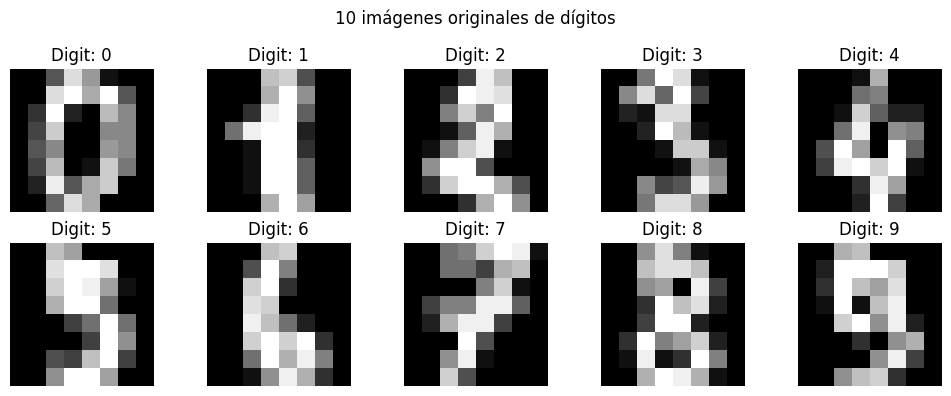

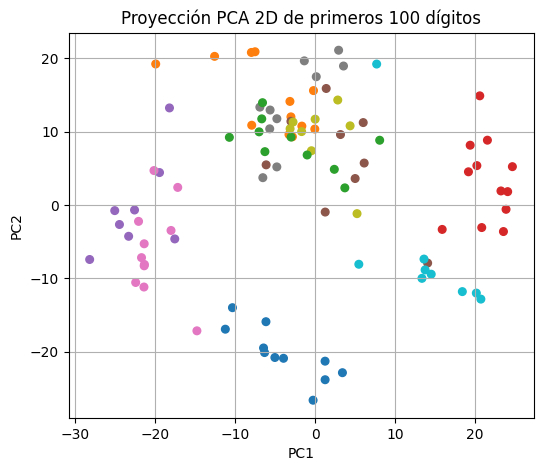

ARI (Adjusted Rand Index) entre clusters y etiquetas reales: 0.6635


In [101]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from numpy.linalg import svd

# a) Cargar y centrar los datos
digits = load_digits()
X = digits.data  # cada imagen es un vector de 64 (8x8)
images = digits.images
labels = digits.target

X_centered = X - X.mean(axis=0)

# Descomposición en valores singulares
U, S, VT = svd(X_centered, full_matrices=False)

# b) Reducir la dimensión a la mitad (64 -> 32)
p = X.shape[1] // 2
X_reduced = X_centered @ VT[:p].T

# c) Graficar 10 imágenes originales
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
for i in range(10):
    axs[i//5, i%5].imshow(images[i], cmap='gray')
    axs[i//5, i%5].axis('off')
    axs[i//5, i%5].set_title(f"Digit: {labels[i]}")
plt.suptitle("10 imágenes originales de dígitos")
plt.tight_layout()
plt.show()

# Proyección a 2D para visualización
proj_2d = X_centered @ VT[:2].T
plt.figure(figsize=(6, 5))
plt.scatter(proj_2d[:100, 0], proj_2d[:100, 1], c=labels[:100], cmap='tab10', s=30)
plt.title("Proyección PCA 2D de primeros 100 dígitos")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# d) Aplicar K-means sobre los datos proyectados
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_reduced)

# Calcular ARI (Adjusted Rand Index)
ari_score = adjusted_rand_score(labels, clusters)
print(f"ARI (Adjusted Rand Index) entre clusters y etiquetas reales: {ari_score:.4f}")